In [1]:
#pip install lightgbm

In [2]:
#pip install xgboost

In [3]:
pip install --upgrade seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


#from catboost import CatBoostRegressor
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import RobustScaler,LabelEncoder
from sklearn.metrics import roc_auc_score,roc_curve, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV



C:\Users\afafc\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\afafc\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [5]:
df = pd.read_csv("D:/DataScienceProjects/Veeraj_projects/Data/Diabetes.csv")
df_copy = df.copy()
df_copy.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


# EDA

In [7]:
def check_df(data, head = 5):
    print("\n******Shape******")
    print(f'Shape: {df.shape}\n'
          f'Size: {df.size}\n'
          f'Dimension: {df.ndim}')
    print("\n******Types*****")
    print(data.dtypes)
    print("\n*****Head*****")
    print(data.head(head))
    print("\n****Tail****")
    print(data.tail(head))
    print("\n***Random Sampling")
    print(data.sample(head))
    print("\n*****Missing Values****")
    print(data.isnull().sum())
    print("\n*****Duplicated Values****")
    print(data.duplicated().sum())
    print("\n******Unique Values")
    print(data.nunique())
    print("\n*****Describe***")
    print(data.describe().T)
    

In [8]:
check_df(df)


******Shape******
Shape: (768, 9)
Size: 6912
Dimension: 2

******Types*****
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

*****Head*****
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2   

In [9]:
'''
   This function returns the names of categorical, numeric and categorical but cardinal variables in the data set.
   Note Categorical variables include categorical variables with numeric appearance.

    Parameters
    ------
        dataframe: dataframe
                Dataframe to get variable names
        cat_th: int, optional
                class threshold for numeric but categorical variables
        car_th: int, optinal
                class threshold for categorical but cardinal variables
    Returns
    ------
        cat_cols: list
                Categorical variable list
        num_cols: list
                Numeric variable list
        cat_but_car: list
                List of cardinal variables with categorical view
    Examples
    ------
        import seaborn as sns
        df = sns.load_dataset("iris")
        print(grab_col_names(df))

    Notes
    ------
        cat_cols + num_cols + cat_but_car = total number of variables
        The sum of 3 lists with return equals the total number of variables: cat_cols + num_cols + cat_but_car = number of variables
    '''


def grab_col_names(dataframe, cat_th = 10, car_th = 20, print_results = True):
    cat_cols = [col for col in dataframe.columns if str(dataframe[col].dtypes) in ["category", "object", "bool"]]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < 10 and str(dataframe[col].dtypes) in ["int64", "float64"]]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > 20 and str(dataframe[col].dtypes) in ["category", "object"]]
    cat_cols = [col for col in cat_cols if col not in cat_but_car]
    cat_cols = cat_cols + num_but_cat
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes in ["int64", "float64"]]
    num_cols = [col for col in num_cols if col not in cat_cols]
    
    if print_results:
        print(f'Observations: {dataframe.shape[0]}')
        print(f'Variables: {dataframe.shape[1]}')
        print(f'cat_cols: {len(cat_cols)}')
        print(f'num_cols: {len(num_cols)}')
        print(f'cat_but_car: {len(cat_but_car)}')
        print(f'num_but_cat: {len(num_but_cat)}')
        
    return cat_cols, num_cols, cat_but_car


In [10]:
cat_cols, num_cols, cat_but_car = grab_col_names(df_copy)

Observations: 768
Variables: 9
cat_cols: 1
num_cols: 8
cat_but_car: 0
num_but_cat: 1


# 1. MISSING VALUE

In [11]:
def check_missing_value(dataframe, na_name=False):
    na_columns = [col for col in dataframe.columns if dataframe[col].isnull().sum() > 0]
    n_miss = dataframe[na_columns].isnull().sum().sort_values(ascending = False)
    ratio = n_miss/dataframe.shape[0] * 100
    missing_df = pd.concat([n_miss, np.round(ratio, 2)], axis = 1, keys =['n_miss', 'ratio'])
    print(missing_df, end = "\n")
    
    if na_name:
        return na_columns
    

In [12]:
check_missing_value(df_copy)

Empty DataFrame
Columns: [n_miss, ratio]
Index: []


There are no missing values in the dataset. Unless when I examine the dataset at the very beginning of notebook, I realised some columns minimum values are "0" which is not possible for some reasons (except Pregnancies).

- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI

Let's also check the BMI lower limit (12) for human survival.

In [13]:
df_copy[df_copy['BMI'] < 12]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
9,8,125,96,0,0,0.0,0.232,54,1
49,7,105,0,0,0,0.0,0.305,24,0
60,2,84,0,0,0,0.0,0.304,21,0
81,2,74,0,0,0,0.0,0.102,22,0
145,0,102,75,23,0,0.0,0.572,21,0
371,0,118,64,23,89,0.0,1.731,21,0
426,0,94,0,0,0,0.0,0.256,25,0
494,3,80,0,0,0,0.0,0.174,22,0
522,6,114,0,0,0,0.0,0.189,26,0
684,5,136,82,0,0,0.0,0.640,69,0



Let's examine the zero-assigned rows and consider them as missing values of these variables.

In [14]:
missing_value = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in missing_value:
    print(col, df_copy.loc[df_copy[col] == 0].shape[0])
    df_copy[col] = np.where(df_copy[col]==0, np.nan, df_copy[col])
    
check_missing_value(df_copy)

Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11
               n_miss  ratio
Insulin           374  48.70
SkinThickness     227  29.56
BloodPressure      35   4.56
BMI                11   1.43
Glucose             5   0.65


## 📌 Why we use Outcome-based median imputation

In this step, missing values are filled using the **median of each feature within each Outcome group** instead of using a global median.

### 🔹 Why group by `Outcome`?

The `Outcome` column represents different populations (e.g., 0 = non-diabetic, 1 = diabetic).  
These groups often have **different distributions** for features like BMI, Glucose, etc.

So filling missing values separately ensures we respect these natural differences.

---


In [15]:
df_copy = df_copy.fillna(df_copy.groupby('Outcome').transform('median'))

# 2. OUTLIER DETECTION & HANDLING

## 📌 Outlier Threshold Function (IQR Method)

This function calculates the **lower and upper limits** for detecting outliers in a numerical column using the Interquartile Range (IQR) method.

---

### 🔹 How it works

1. It calculates the **10th percentile (Q1-like)** and **90th percentile (Q3-like)** of the selected variable.
2. It computes the **Interquartile Range (IQR)** as:
   \[
   IQR = Q3 - Q1
   \]
3. It defines outlier boundaries using the standard IQR rule:
   - Lower limit = Q1 - 1.5 × IQR
   - Upper limit = Q3 + 1.5 × IQR

---

### 🔹 Purpose

Any value below the lower limit or above the upper limit is considered an **outlier**.

This helps in identifying extreme values that may distort analysis or model performance.

---

### 🔹 Output

The function returns:
- `low_limit` → lower bound for outliers  
- `up_limit` → upper bound for outliers  

---

### 🔹 Key idea

Instead of manually guessing outliers, this method uses statistical boundaries based on data distribution to detect them in a consistent way.

In [16]:
def outlier_thresholds(dataframe, variable, low_quantile = 0.10, up_quantile =0.90):
    quantile_one = dataframe[variable].quantile(low_quantile) #Finds the value below which 10% of data lies
    quantile_three = dataframe[variable].quantile(up_quantile) #Finds the value below which 90% of data lies
    interquantile_range = quantile_three - quantile_one
    up_limit = quantile_three + 1.5*interquantile_range
    low_limit = quantile_one - 1.5*interquantile_range
    return low_limit, up_limit

In [17]:
#Returns True if the column has any outliers, otherwise False
def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    
    if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True
    else:
        return False

In [18]:
def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)

    outlier_condition = (
        (dataframe[col_name] > up_limit) |
        (dataframe[col_name] < low_limit)
    )

    return outlier_condition.any()

In [19]:
for col in num_cols:
    print(col,": ", check_outlier(df_copy, col))

Pregnancies :  False
Glucose :  False
BloodPressure :  False
SkinThickness :  True
Insulin :  True
BMI :  False
DiabetesPedigreeFunction :  True
Age :  False


## 📌 Outlier Handling (Capping / Winsorization)

This function handles outliers by **capping extreme values** instead of removing them.

---

### 🔹 How it works

1. It calculates lower and upper outlier limits using the IQR-based method.
2. Any value below the lower limit is replaced with the lower limit.
3. Any value above the upper limit is replaced with the upper limit.

---

### 🔹 Why we cap instead of remove

- Removing outliers deletes entire rows and causes loss of useful information in other columns.
- Capping preserves all data points while reducing the impact of extreme values.
- This helps maintain dataset size and structure, which is important for machine learning models.

---

### 🔹 Key idea

Outliers are not deleted — they are **clipped to the nearest valid threshold** so that they do not distort the analysis or model training.

In [20]:
def replace_with_thresholds(dataframe, variable):
    low_limit, up_limit = outlier_thresholds(dataframe, variable)
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

In [21]:
for col in num_cols:
    df_copy[col] = df_copy[col].astype(float)
    print(col, replace_with_thresholds(df_copy, col))

Pregnancies None
Glucose None
BloodPressure None
SkinThickness None
Insulin None
BMI None
DiabetesPedigreeFunction None
Age None


# 3. CORRELATION

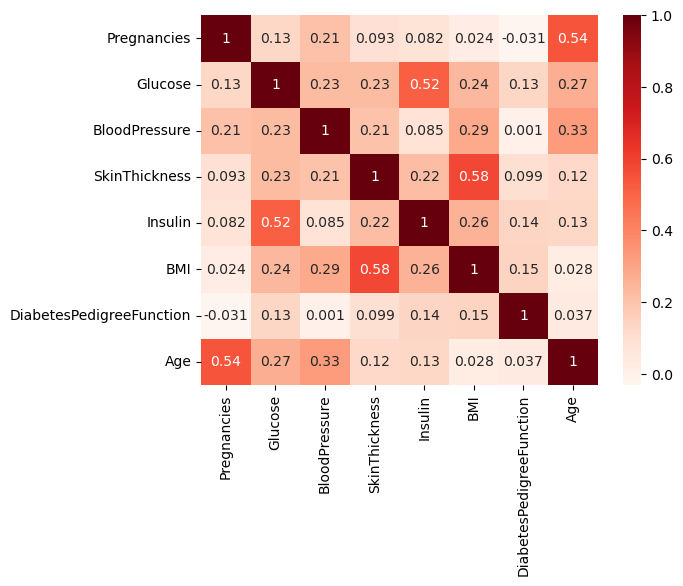

In [22]:
corr = df_copy[num_cols].corr()
sns.heatmap(corr, cmap="Reds", annot=True);

# 4. FEATURE EXTRACTION

In [23]:
def feature_extraction(dataframe):
    dataframe['Insulin_CAT'] = pd.cut(x = dataframe['Insulin'],
                                      bins = [0, 140, 190, np.inf], 
                                      labels = ["Normal", "Prediabetes", "Diabetes"])
    
    dataframe['BloodPressure_CAT'] = pd.cut(x=dataframe['BloodPressure'], 
                                            bins = [0, 60, 80, 90, 120, np.inf],
                                            labels = ["Low_Blood_Pressure", "Normal",
                                                      "Prehypertension", "Hypertension",
                                                      "Hypertensive_Crisis"])
    
    dataframe['Glucose_CAT'] = pd.cut(x=dataframe['Glucose'],
                                      bins=[0, 140, 199, np.inf],
                                      labels=["Normal", "Impaired_Glucose_Tolerance",
                                              "Diabetes"])

    dataframe['BMI_CAT'] = pd.cut(x=dataframe['BMI'],
                                  bins=[0, 18.5, 24.9, 29.9, 34.9, 39.9,  np.inf],
                                  labels=["Underweight", "Healthy", "Overweight",
                                          "Obese_Class1", "Obese_Class2", "Obese_Class3"])

    dataframe['Age_CAT'] = pd.cut(x=dataframe['Age'],
                                  bins=[20, 40, 60, np.inf],
                                  labels=["Adult", "Middle_Age_Adult", "Senior_Adult"])
    
    dataframe.loc[(dataframe['Age'] > 40)
                  & (dataframe['BloodPressure_CAT'] == 'Hypertension')
                  & ((dataframe['BMI_CAT'] == 'Overweight')
                     | (dataframe['BMI_CAT'] == 'Obese_Class1')
                     | (dataframe['BMI_CAT'] == 'Obese_Class2')
                     | (dataframe['BMI_CAT'] == 'Obese_Class3')), "Life_Level_CAT"] = "At_Risk"
    
    dataframe["Life_Level_CAT"] = dataframe["Life_Level_CAT"].fillna("Not_Risk")
                     
                
    

In [24]:
feature_extraction(df_copy)

# 5.VISUALIZATION

## I. OUTLIERS

In [25]:
def boxplot_for_outliers(dataframe):
    a = 2
    b = 4
    c = 1
    results = []
    colors = []
    
    palette_set3 = sns.color_palette("Set3", len(num_cols))
    for color in palette_set3.as_hex():
        colors.append(color)
    colour_num_cols = zip(num_cols, colors)
    
    fig = plt.figure(figsize = (20, 10))
    for col, color in colour_num_cols:
        plt.subplot(a,b,c)
        sns.boxplot(dataframe[col], color = color)
        plt.xlabel(f'{dataframe[col].name}', size=25)
        plt.yticks(fontsize=18)
        c = c + 1
        results.append(check_outlier(dataframe, col))
        if True in results:
            plt.suptitle(f'Original Dataset', size = 25)
        else:
            plt.suptitle(f'Cleaned Dataset', size = 25)
    
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.25)
    plt.show()
    
    

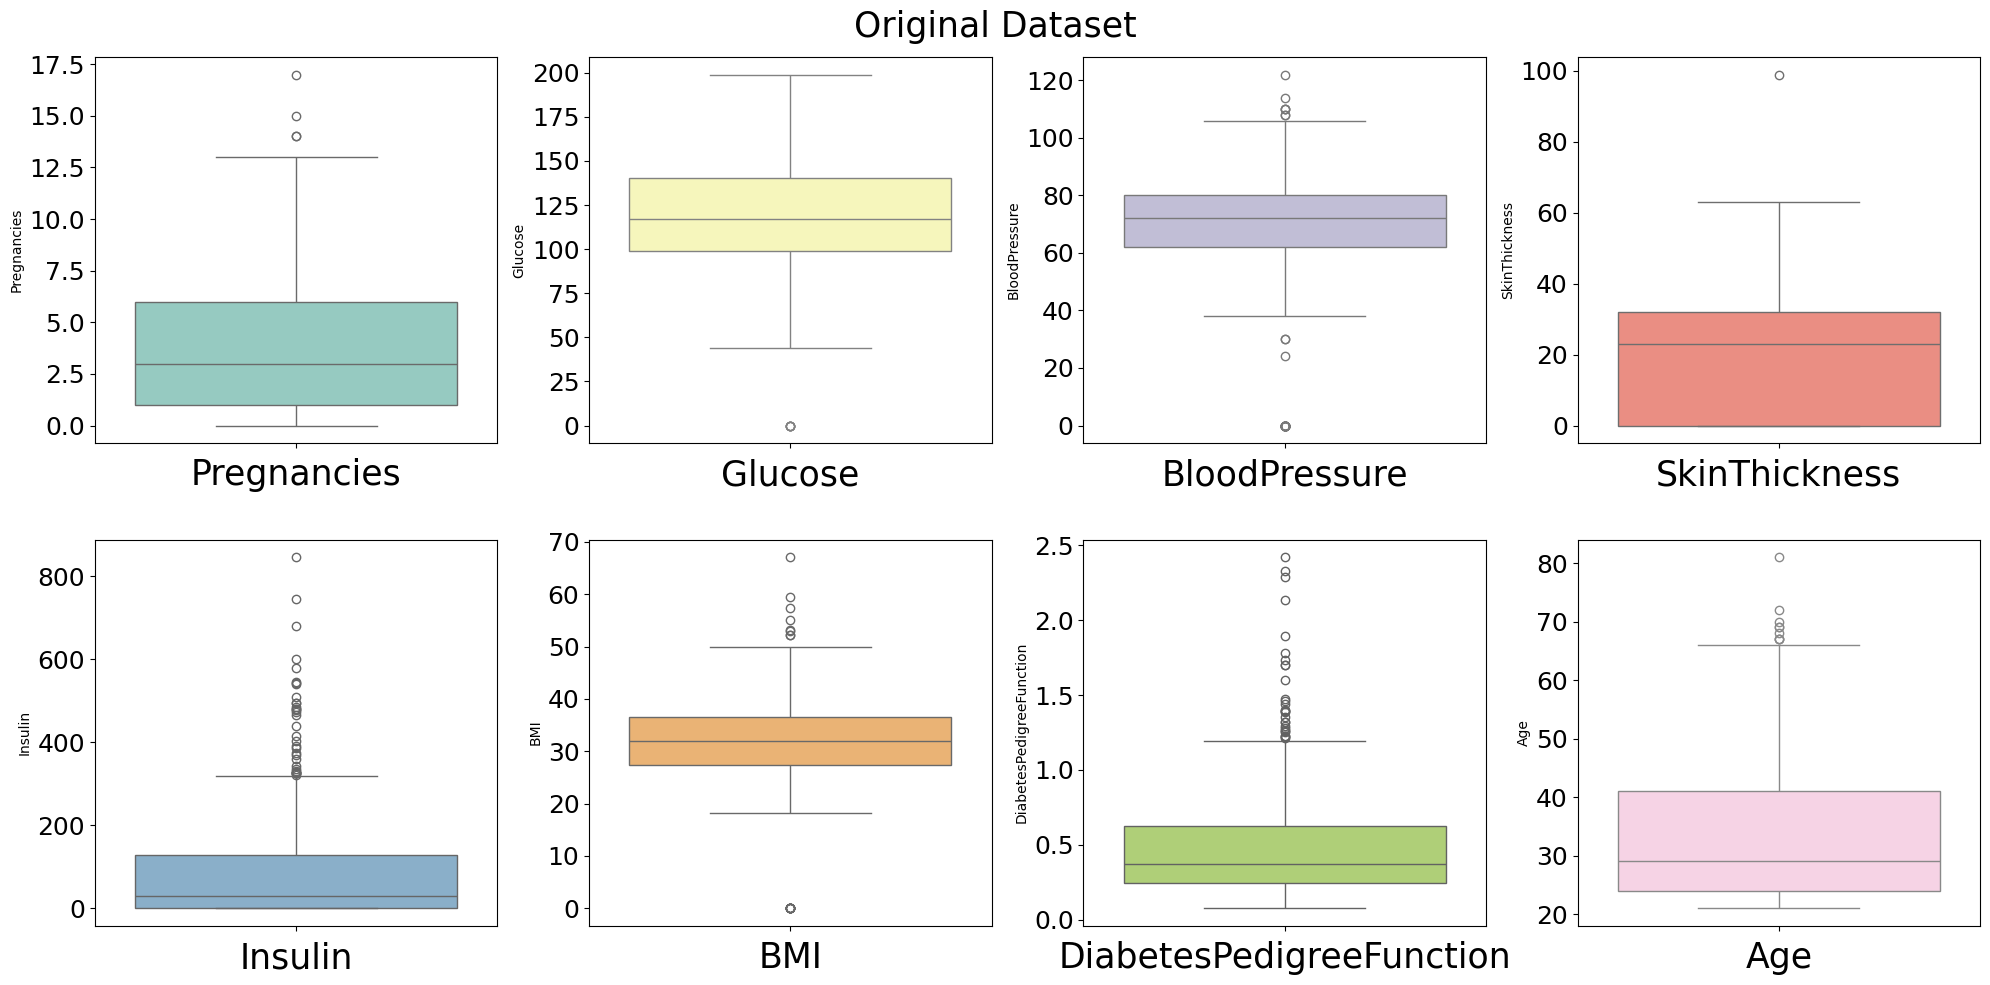

In [26]:
boxplot_for_outliers(df)


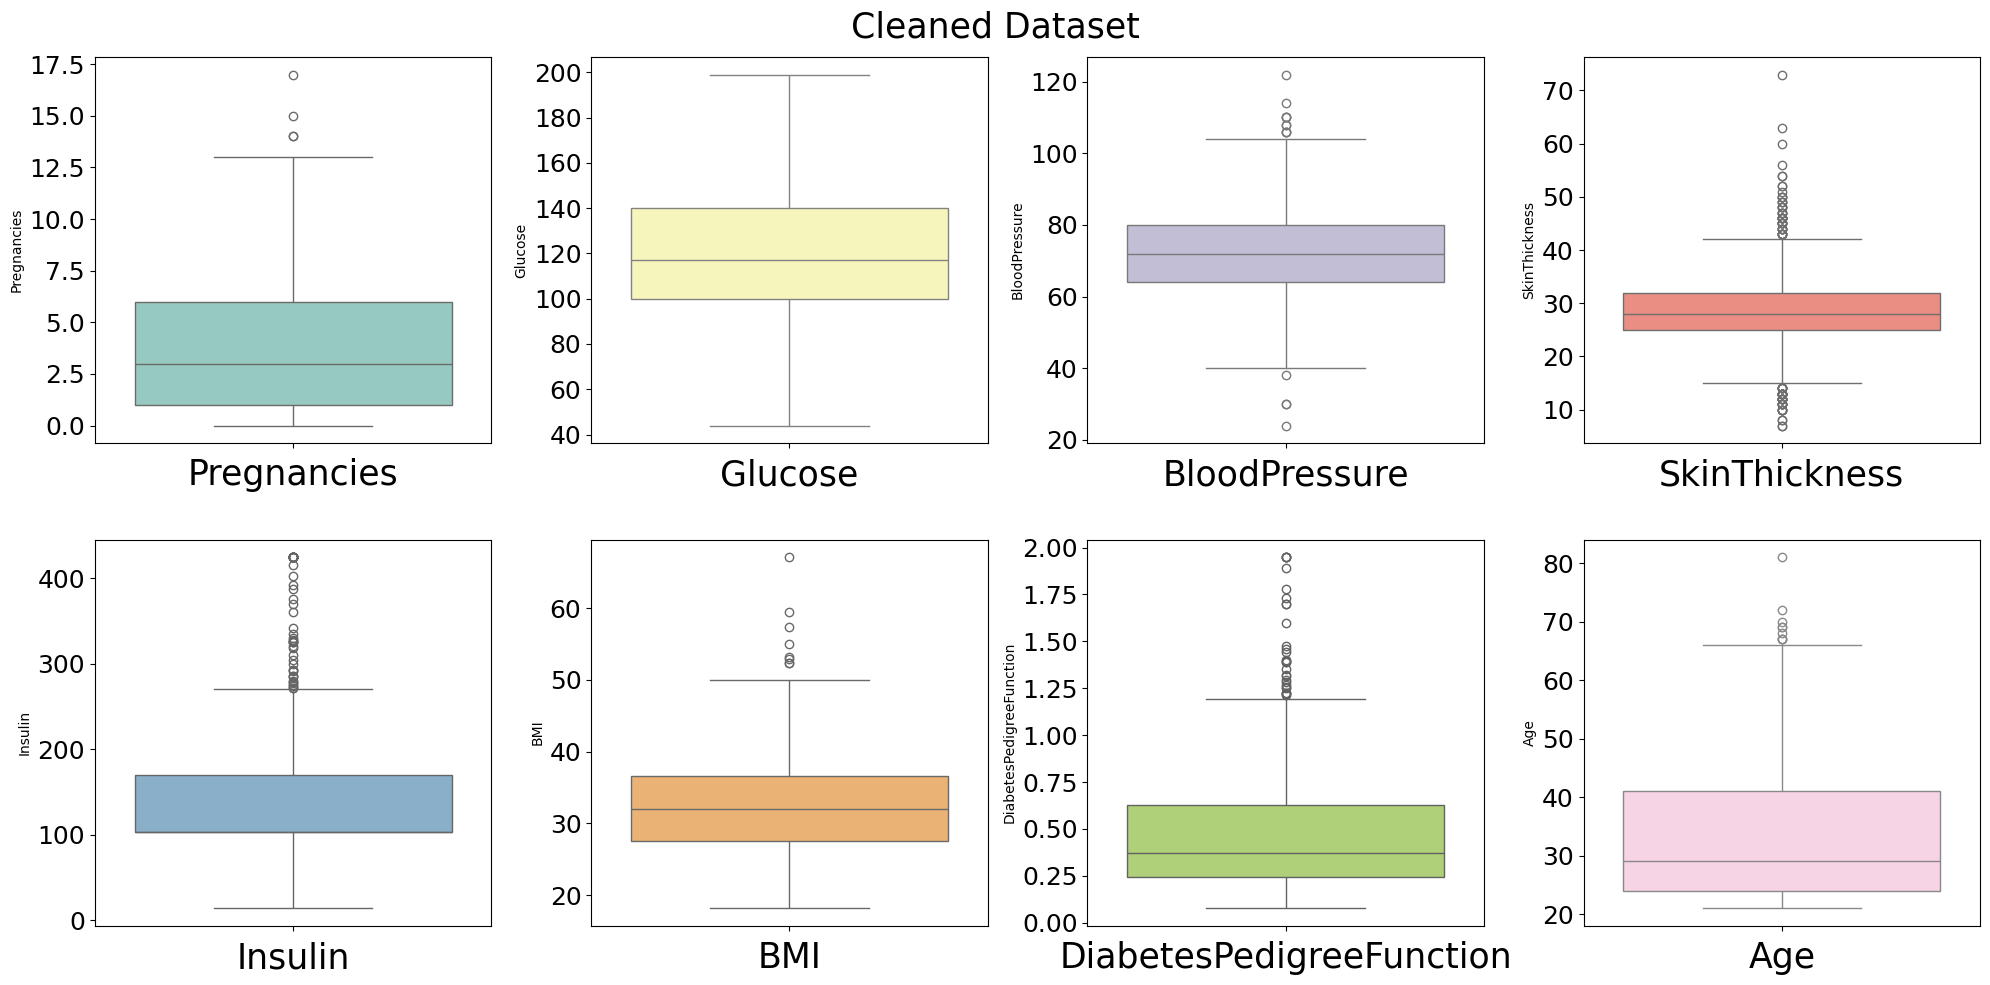

In [27]:
boxplot_for_outliers(df_copy)

## II. DISTRIBUTION

In [28]:
def hist_plot(dataframe, title):
    a = 4
    b = 2
    c = 1
    colors = []
    missing_cols =["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
    palette_set2 = sns.color_palette("Paired", len(num_cols))
    for color in palette_set2.as_hex():
        colors.append(color)
    colour_num_cols = zip(missing_cols, colors)
    
    fig = plt.figure(figsize = (13, 15))
    for col, color in colour_num_cols:
        plt.subplot(a,b,c)
        sns.histplot(data=dataframe, x=col, kde=True, color=color)
        plt.xlabel(f'{dataframe[col].name}', size =15)
        c = c+1
        plt.suptitle(title, size=18);
        
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.25)
    plt.show()

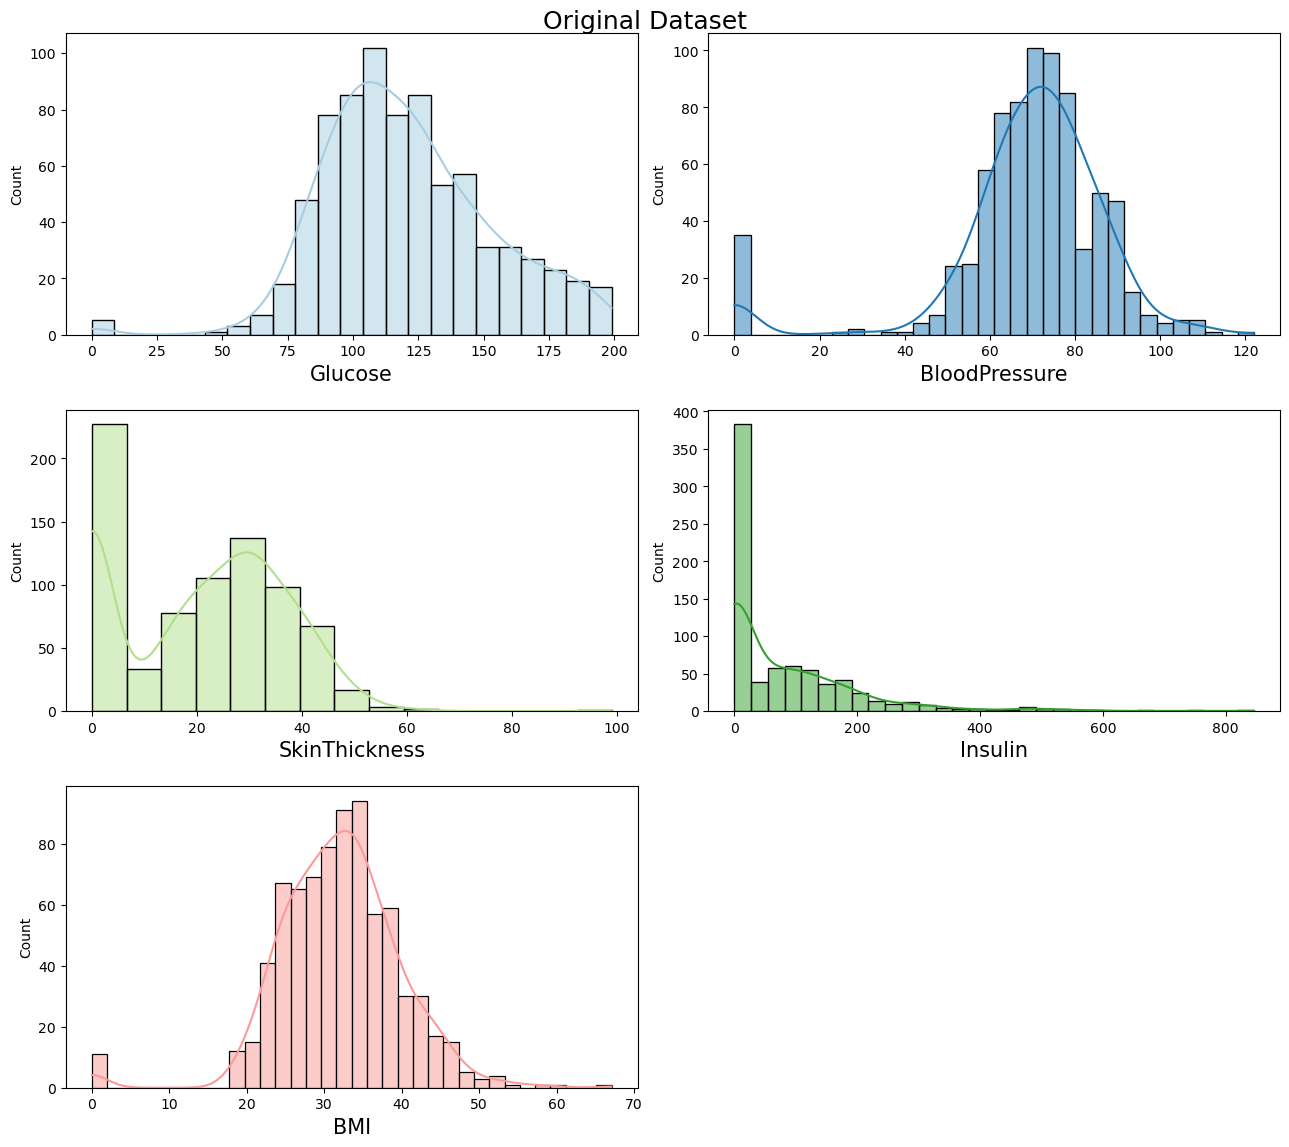

In [29]:

hist_plot(df, title='Original Dataset')


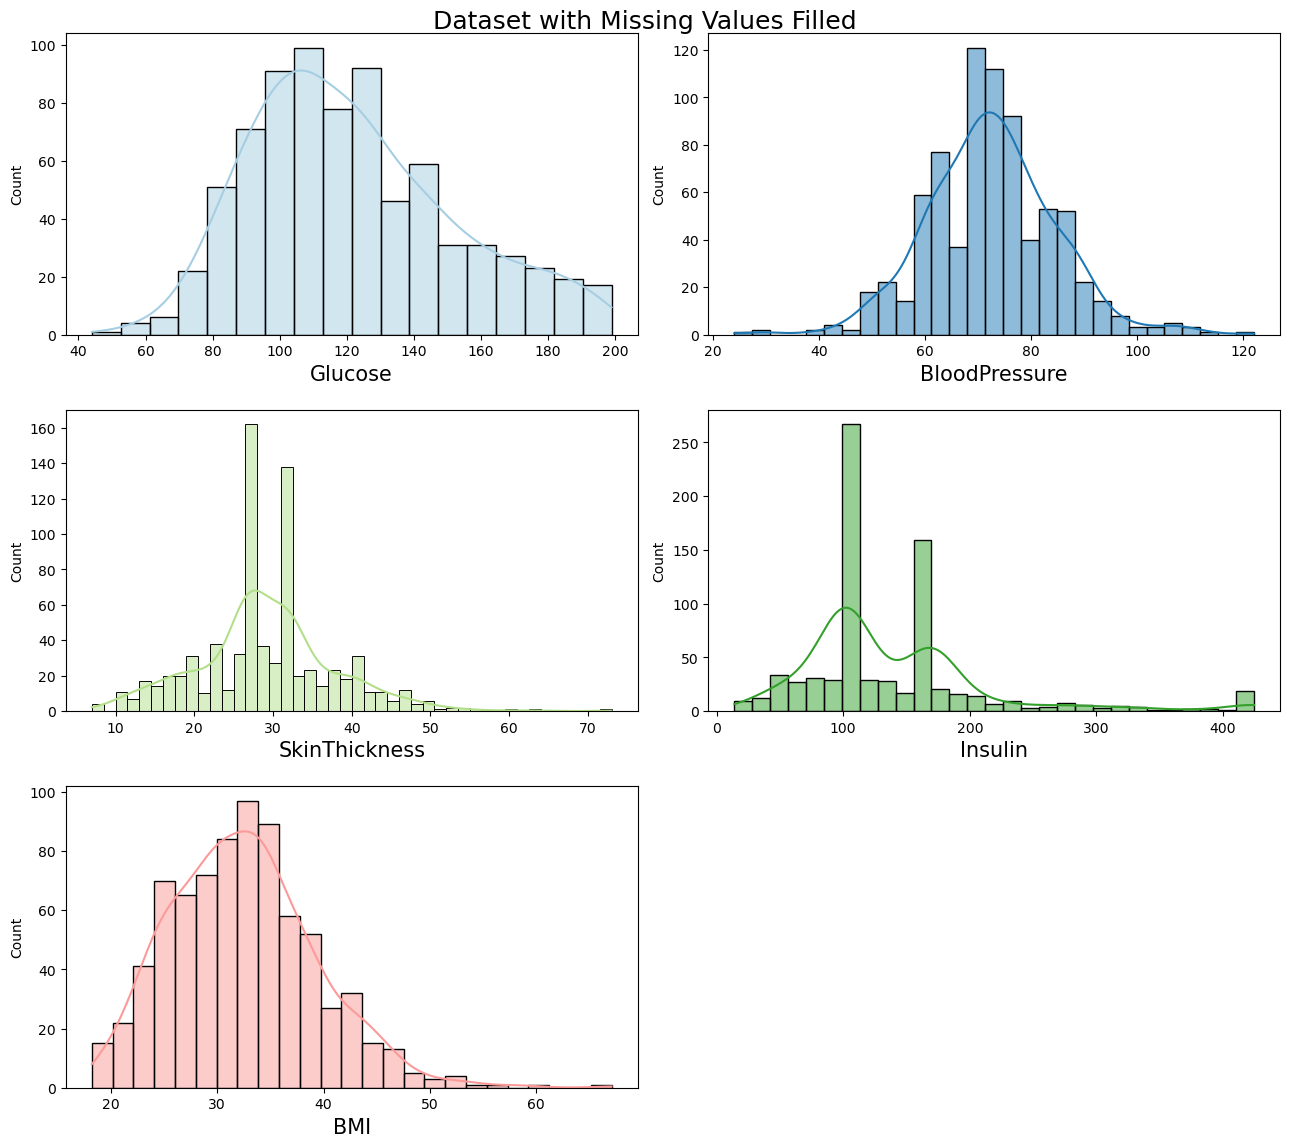

In [30]:
hist_plot(df_copy, title='Dataset with Missing Values Filled')

The original distributions contained many invalid zero values representing missing data. After imputing these values, the zero spikes disappeared and observations were redistributed to more realistic ranges, leading to higher frequencies in the central part of the distributions.

## III, DIABETES RATIO

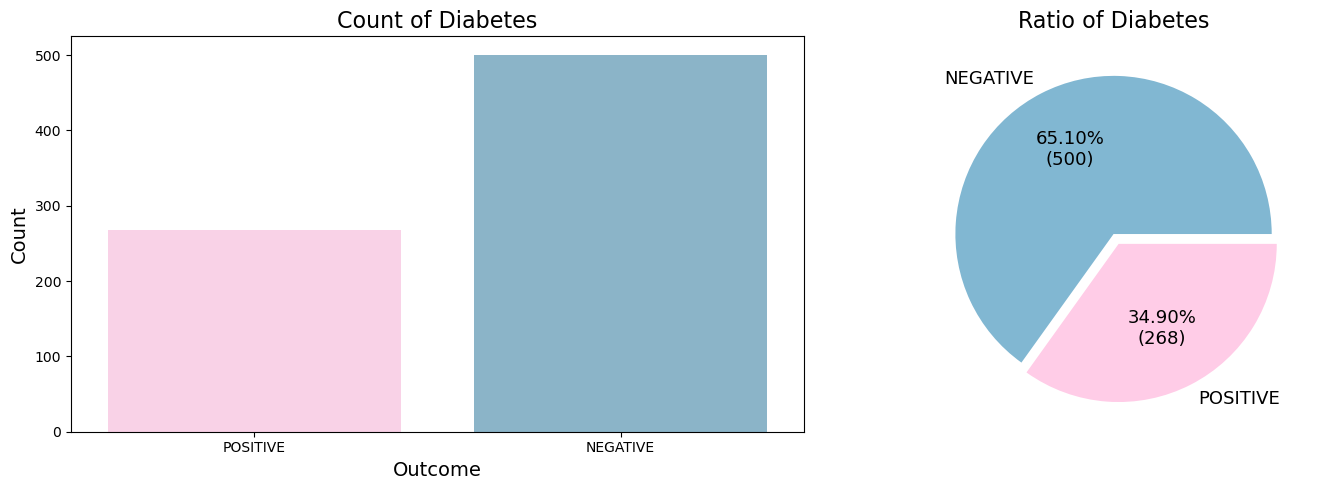

In [31]:
fig,  axs = plt.subplots(1,2, figsize = (15, 5))

ax = sns.countplot(data=df_copy,
                   x=df_copy['Outcome'].replace({0: 'NEGATIVE', 1: 'POSITIVE'}),
                   ax = axs[0],
                   palette=["#ffcce7", "#81b7d2"]);

ax.set_xlabel('Outcome', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
axs[0].set_title("Count of Diabetes", fontsize=16)

def func(pct, allvals):
    absolute = int(np.round(pct/100.*np.sum(allvals)))
    return f"{pct:.2f}%\n({absolute:d})"

ax2 = df_copy['Outcome'].value_counts().plot.pie(explode=[0,0.07],
                                                 colors=["#81b7d2", "#ffcce7"],
                                                 autopct=lambda pct: func(pct, df['Outcome'].value_counts()),
                                                 ylabel='',
                                                 labels=['NEGATIVE', 'POSITIVE'],
                                                 ax = axs[1],
                                                 textprops=dict(color="black", size=13));
axs[1].set_title("Ratio of Diabetes", fontsize=16)

plt.tight_layout()
plt.show()

# 6. VISUALIZATION OF EXTRACTED FEATURES

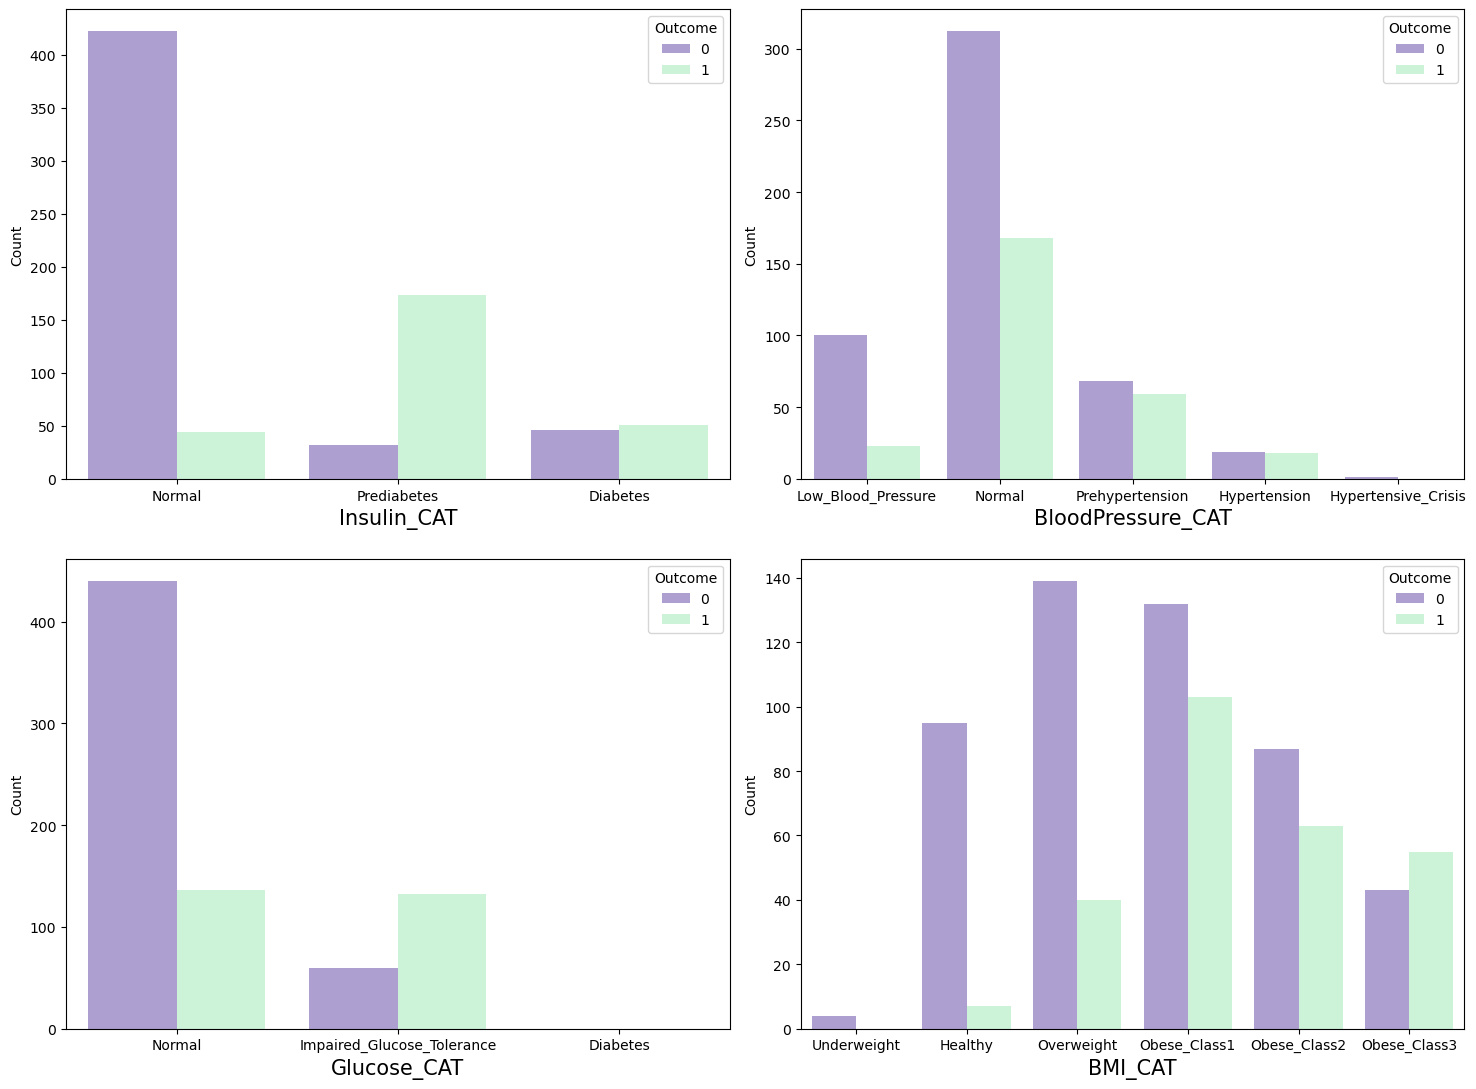

In [32]:
new_cols =['Insulin_CAT', 'BloodPressure_CAT', 'Glucose_CAT', 'BMI_CAT']

a = 2
b = 2
c = 1

fig = plt.figure(figsize = (15, 11))
for col in new_cols:
    plt.subplot(a, b, c)
    ax = sns.countplot(df_copy,
                       x = df_copy[col],
                       hue = df.Outcome,
                       palette = ["#AA96DA", "#C5FAD5"])
    plt.ylabel('Count')
    plt.xlabel(f'{col}', size = 15)
    c = c + 1
    
plt.tight_layout()
plt.subplots_adjust(hspace = 0.17)
plt.show()
    

Insulin category shows the clearest separation: people with "Normal" insulin levels are overwhelmingly non-diabetic (around 420 vs. 45), but the "Prediabetes" insulin bin flips dramatically, with roughly 170 diabetic cases against only about 30 non-diabetic ones. The "Diabetes" insulin bin is roughly balanced. This makes insulin one of the strongest predictors in this set, since abnormal insulin readings track closely with the diabetes outcome.

Blood pressure category is less discriminating. Most people, diabetic or not, fall into the "Normal" BP range, and the non-diabetic group dominates every bin in raw counts. Still, the proportion of diabetic cases creeps up through prehypertension and hypertension, suggesting a weak positive association rather than a strong one.

Glucose category echoes the insulin pattern. "Normal" glucose is dominated by non-diabetic cases, while "Impaired Glucose Tolerance" has a near 50/50 split with a notably higher diabetic share than the normal group, indicating glucose tolerance is also a meaningful risk marker. Almost no one falls into the "Diabetes" glucose bin itself, which likely just reflects sparse data there rather than a real trend.

BMI category shows a steady gradient: in the "Healthy" and "Overweight" bins, non-diabetic cases far outnumber diabetic ones, but that gap narrows progressively through Obese Class 1 and 2, and by Obese Class 3 the diabetic count actually exceeds the non-diabetic count. This is a clean dose-response pattern, higher BMI bins, higher relative diabetes risk.

Put together, these four panels point to insulin, glucose, and BMI as the variables most clearly separating diabetic from non-diabetic outcomes, while blood pressure plays a smaller, secondary role. 

# MACHINE LEARNING

Encoding is the process of converting categorical data into numerical form for machine learning. Common techniques include Label Encoding for binary categories, One-Hot Encoding for unordered categories, Ordinal Encoding for ordered categories, Frequency Encoding for high-cardinality features, and Target Encoding for advanced predictive modeling.

One-Hot Encoding is a preprocessing technique that converts categorical variables into binary (0/1) columns. This allows machine learning algorithms to process categorical data without introducing an artificial order between categories. Each category is represented by its own indicator column, and drop_first=True is often used to avoid multicollinearity by removing one redundant category.

In [33]:
def one_hot_encoder(dataframe, categorical_col, drop_first = True):
    dataframe = pd.get_dummies(dataframe, columns=categorical_col, drop_first=drop_first)
    return dataframe

Label Encoding converts categorical values into numerical labels. In this function, LabelEncoder() is used to transform a binary categorical column into 0s and 1s. The encoder first learns the unique categories (fit) and then replaces them with numeric labels (transform). This approach is particularly suitable for binary variables and target labels.

In [93]:
def label_encoding(dataframe, binary_col):
    labelencoder = LabelEncoder()
    dataframe[binary_col] = labelencoder.fit_transform(dataframe[binary_col])
    return dataframe

The code temporarily combines the feature matrix (X) and target variable (y) into a single DataFrame by matching rows using their indices. This allows preprocessing operations that require access to the Outcome column

In [113]:
def data_prep(X, y):
    index = X.index
    dataframe = X.merge(y.to_frame(), left_index = True, right_index = True).set_index(index)
    
    #get_cols
    cat_cols, num_cols, cat_but_car = grab_col_names(dataframe, print_results = False)
    
    for col in num_cols:
        dataframe[col] = dataframe[col].astype(float)
    
    # replace outliers
    [replace_with_thresholds(dataframe, col) for col in num_cols]
    
    missing_values = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
    for col in missing_values:
        dataframe[col] = np.where(dataframe[col] == 0, np.nan, dataframe[col])
    dataframe = dataframe.fillna(dataframe.groupby('Outcome').transform('median'))
    
    # Feature Engineering
    feature_extraction(dataframe)
    
    #Scaling
    
    """RobustScaler is less sensitive to outliers because it scales data using the median 
    and interquartile range (IQR), both of which are resistant to extreme values, unlike 
    the mean and standard deviation used by StandardScaler
    
    After Robust Scaling, numerical variables are centered around the median,
    where values close to 0 represent typical observations, positive values 
    indicate above-median observations, and negative values indicate 
    below-median observations.
    
    """
    
    rs = RobustScaler()
    dataframe[num_cols] = rs.fit_transform(dataframe[num_cols])
    
    
    binary_cols = [col for col in dataframe.columns 
                   if dataframe[col].dtype not in ("int64", "float64")
                   and dataframe[col].nunique() == 2]
    
    for col in binary_cols:
        label_encoding(dataframe, col)
        
    
    #One-hot-encoding
    
    ohe_cols = [col for col in dataframe.columns 
               if 12 >= dataframe[col].nunique() > 2]
    dataframe = one_hot_encoder(dataframe, ohe_cols, drop_first = True)
    
    
    X = dataframe.drop(['Outcome'], axis = 1)
    y = dataframe['Outcome']
    
    X = X.astype(np.float64)
    
    return X, y
    
    

The dataset was divided into features (X) and the target variable (y). The Outcome column was removed from X and stored separately as y. The data was then split into training and testing sets using train_test_split(), with 80% of the observations used for model training and 20% reserved for evaluation. The parameter random_state=42 ensures that the same random split is generated each time the code is executed, enabling reproducible results.

In [95]:
X = df.drop(["Outcome"], axis = 1)
y = df["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)


🚀 First take a look baseline scores of raw datasets. That's why I fit the models just before data preprocessing.

In [96]:
def base_models(X, y, scoring="roc_auc"):
    print("Base Models....")
    
    classifiers = [('LR', LogisticRegression()),
                   ('KNN', KNeighborsClassifier()),
                   ("CART", DecisionTreeClassifier()),
                   ("RF", RandomForestClassifier()),
                   ('GBM', GradientBoostingClassifier()),
                   ('XGBoost', XGBClassifier(use_label_encoder=False, eval_metric='logloss')),
                   ('LightGBM', LGBMClassifier(verbose=-1))
                   ]

    for name, classifier in classifiers:
        cv_results = cross_validate(classifier, X, y, cv=3, scoring=scoring)
        print(f"{scoring}: {round(cv_results['test_score'].mean(), 4)} ({name}) ")

base_models(X_train, y_train, scoring="accuracy")

Base Models....
accuracy: 0.7671 (LR) 
accuracy: 0.7182 (KNN) 
accuracy: 0.7296 (CART) 
accuracy: 0.7703 (RF) 
accuracy: 0.7654 (GBM) 
accuracy: 0.7524 (XGBoost) 
accuracy: 0.7378 (LightGBM) 


In [97]:
X_train, y_train = data_prep(X_train, y_train)
X_test, y_test = data_prep(X_test, y_test)

In [114]:
def base_models(X, y):
    models = [("LR", LogisticRegression(solver='lbfgs', max_iter=3000)),
              #("KNN", KNeighborsClassifier()),
              ("CART", DecisionTreeClassifier()),
              ("RF", RandomForestClassifier()),
              ("GBM", GradientBoostingClassifier()),
              ("XGBoost", XGBClassifier(eval_metric='logloss')),
              ("LightGBM", LGBMClassifier()),]
    for name, classifier in models:
        cv_results = cross_validate(classifier, X, y, cv=5, scoring="accuracy")
        print(f"Accuracy: {round(cv_results['test_score'].mean(), 4)} ({name}) ")

In [115]:
#knn_params = {"knn__n_neighbors": range(5, 50)}

cart_params = {'max_depth': range(1, 20),
               "min_samples_split": range(2, 30)}

rf_params = {"max_depth": [8, 15, None],
             "max_features": [5, 7],
             "min_samples_split": [15, 20],
             "n_estimators": [200, 300]}

xgboost_params = {"learning_rate": [0.1, 0.01],
                  "max_depth": [5, 8],
                  "n_estimators": [100, 200],
                  "colsample_bytree": [0.5, 1]}

lightgbm_params = {"learning_rate": [0.01, 0.1],
                   "n_estimators": [300, 500, 1500],
                   "colsample_bytree": [0.5, 0.7, 1]}

In [116]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])



classifiers  =[#('KNN', knn_pipe, knn_params),
               ("CART", DecisionTreeClassifier(), cart_params),
               ("RF", RandomForestClassifier(), rf_params),
               ('XGBoost', XGBClassifier(eval_metric='logloss'), xgboost_params),
               ('LightGBM', LGBMClassifier(), lightgbm_params)]

In [117]:
def hyperparameter_optimization(X, y, cv=5, scoring="accuracy"):
    print("\nHyperparameter Optimization....")
    best_models = {}
    for name, classifier, params in classifiers:
        print(f"########## {name} ##########")
        cv_results = cross_validate(classifier, X, y, cv=cv, scoring=scoring)
        print(f"{scoring} (Before): {round(cv_results['test_score'].mean(), 4)}")

        gs_best = GridSearchCV(classifier, params, cv=cv, n_jobs=-1, verbose=False).fit(X, y)
        final_model = classifier.set_params(**gs_best.best_params_)

        cv_results = cross_validate(final_model, X, y, cv=cv, scoring=scoring)
        print(f"{scoring} (After): {round(cv_results['test_score'].mean(), 4)}")
        print(f"{name} best params: {gs_best.best_params_}", end="\n\n")
        best_models[name] = final_model
    return best_models

In [125]:
def voting_classifier(best_models, X, y):
    print("\nVoting Classifier...")
    voting_clf = VotingClassifier(estimators=[#('KNN', best_models["KNN"]),
                                              ('RF', best_models["RF"]),
                                              ('XGBoost', best_models["XGBoost"]),
                                              ('LightGBM', best_models["LightGBM"])],
                                  voting='soft').fit(X, y)
    cv_results = cross_validate(voting_clf, X, y, cv=3, scoring=["accuracy", "f1", "roc_auc"])
    print(f"Accuracy: {cv_results['test_accuracy'].mean()}")
    print(f"F1Score: {cv_results['test_f1'].mean()}")
    print(f"ROC_AUC: {cv_results['test_roc_auc'].mean()}")
    return voting_clf

In [119]:
print(X_train.isnull().sum())
print(y_train.isnull().sum())

Pregnancies                              0
Glucose                                  0
BloodPressure                            0
SkinThickness                            0
Insulin                                  0
BMI                                      0
DiabetesPedigreeFunction                 0
Age                                      0
Glucose_CAT                              0
Life_Level_CAT                           0
Insulin_CAT_Prediabetes                  0
Insulin_CAT_Diabetes                     0
BloodPressure_CAT_Normal                 0
BloodPressure_CAT_Prehypertension        0
BloodPressure_CAT_Hypertension           0
BloodPressure_CAT_Hypertensive_Crisis    0
BMI_CAT_Healthy                          0
BMI_CAT_Overweight                       0
BMI_CAT_Obese_Class1                     0
BMI_CAT_Obese_Class2                     0
BMI_CAT_Obese_Class3                     0
Age_CAT_Middle_Age_Adult                 0
Age_CAT_Senior_Adult                     0
dtype: int6

In [126]:
def fit_models(X,y):
    base_models(X, y)
    best_models = hyperparameter_optimization(X, y)
    voting_clf = voting_classifier(best_models, X, y)
    return voting_clf, best_models

voting_clf, best_models = fit_models(X_train, y_train)


Accuracy: 0.8665 (LR) 
Accuracy: 0.8355 (CART) 
Accuracy: 0.8926 (RF) 
Accuracy: 0.886 (GBM) 
Accuracy: 0.8958 (XGBoost) 
Accuracy: 0.8942 (LightGBM) 

Hyperparameter Optimization....
########## CART ##########
accuracy (Before): 0.8616
accuracy (After): 0.8616
CART best params: {'max_depth': 9, 'min_samples_split': 29}

########## RF ##########
accuracy (Before): 0.8796
accuracy (After): 0.8779
RF best params: {'max_depth': None, 'max_features': 5, 'min_samples_split': 20, 'n_estimators': 200}

########## XGBoost ##########
accuracy (Before): 0.9088
accuracy (After): 0.9088
XGBoost best params: {'colsample_bytree': 0.5, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

########## LightGBM ##########
accuracy (Before): 0.9023
accuracy (After): 0.9023
LightGBM best params: {'colsample_bytree': 0.5, 'learning_rate': 0.1, 'n_estimators': 1500}


Voting Classifier...
Accuracy: 0.8925235134704289
F1Score: 0.8420979986197378
ROC_AUC: 0.9516383453904891


In [123]:
lgbm_model = best_models['LightGBM'].fit(X_train, y_train)

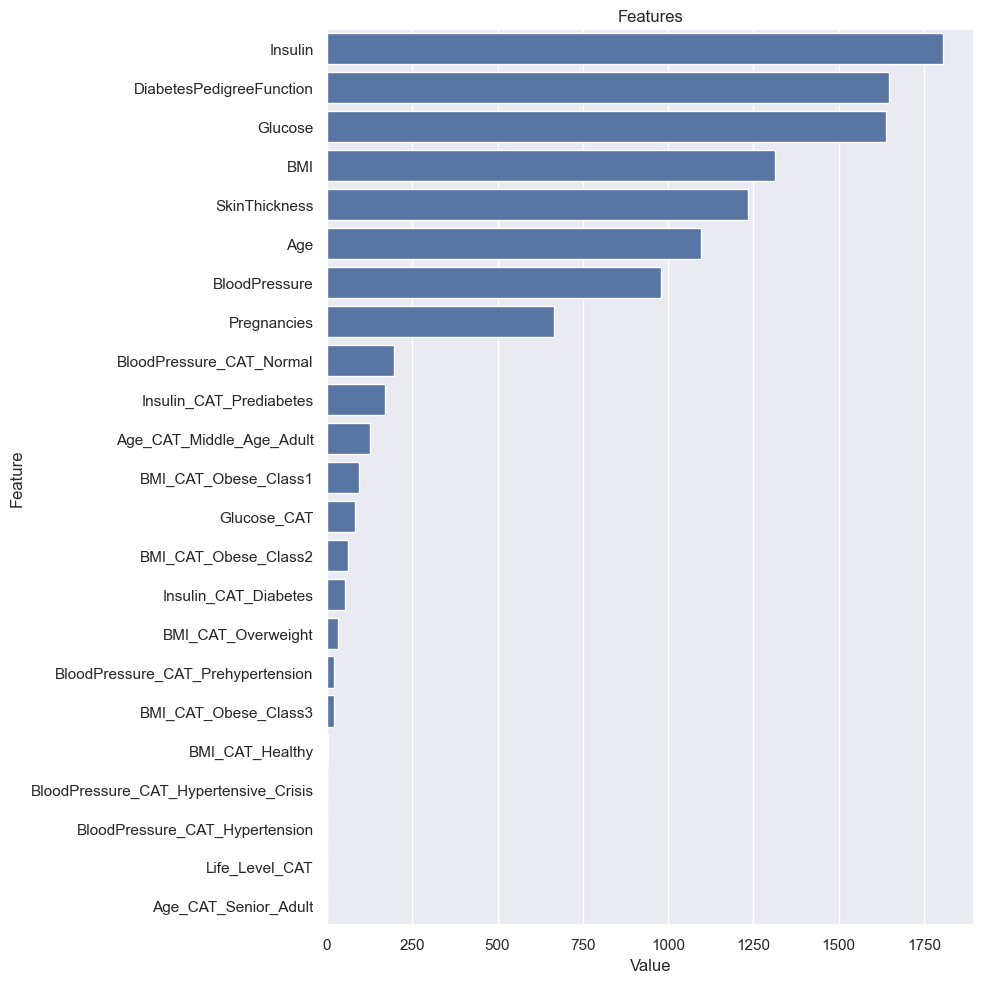

In [124]:
def plot_importance(model, features, num=len(X)):
    feature_imp = pd.DataFrame({'Value': model.feature_importances_,
                                'Feature': features.columns})
    plt.figure(figsize=(10, 10))
    sns.set(font_scale=1)
    sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value",
                                                                     ascending=False)[0:num])
    plt.title('Features')
    plt.tight_layout()
    plt.show()

plot_importance(lgbm_model, X_train)

# MODEL PERFORMANCE

- Confusion Matrix : also known as the error matrix, allows visualization of the performance of an algorithm :

  - true positive (TP) : Diabetic correctly identified as diabetic
  - true negative (TN) : Healthy correctly identified as healthy
  - false positive (FP) : Healthy incorrectly identified as diabetic
  - false negative (FN) : Diabetic incorrectly identified as healthy
- Metrics :

  - Accuracy : How many prediction we made were true?
 

  - Precision : The proportion of positive cases that were correctly identified.
 

  - Recall : The proportion of actual positive cases which are correctly identified.
 

  - F1 Score : F1-Score is the harmonic mean of precision and recall values for a classification problem.
 

  - ROC Curve : The ROC curve is created by plotting the true positive rate (TPR) against the false positive rate (FPR) at various threshold settings.

In [127]:
y_pred = lgbm_model.predict(X_test)
y_prob = lgbm_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.93      0.90        99
           1       0.86      0.76      0.81        55

    accuracy                           0.87       154
   macro avg       0.87      0.85      0.85       154
weighted avg       0.87      0.87      0.87       154



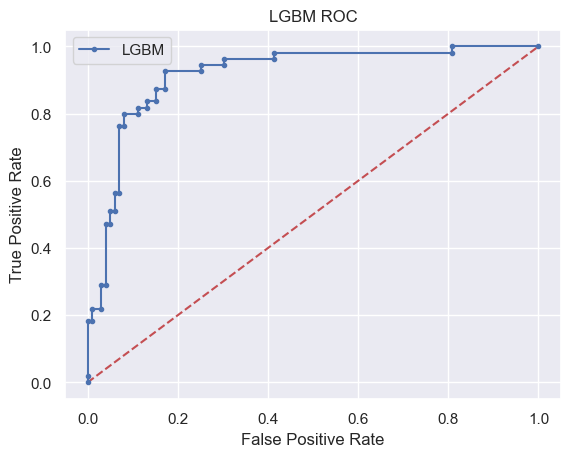

In [128]:
lgbm_roc_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure()

plt.plot([0,1],[0,1],'r--')
plt.plot(fpr, tpr, marker='.', label='LGBM')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("LGBM ROC")
plt.legend()
plt.show()

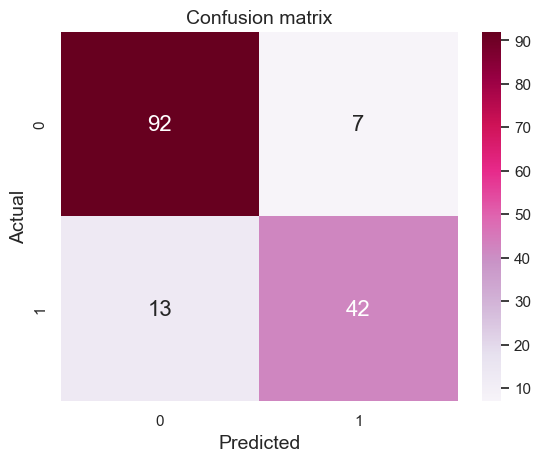

In [129]:
cnf_matrix = confusion_matrix(y_test, y_pred)
p = sns.heatmap(pd.DataFrame(cnf_matrix),
                annot=True,
                cmap="PuRd",
                annot_kws={"size": 16})
plt.title('Confusion matrix', size=14)
plt.ylabel('Actual', size=14)
plt.xlabel('Predicted', size=14);

CONCLUSION
My finding shows that Glucose, Insulin, and BMI, respectively, have the most influence on a person's diabetes outcome. New features have more or less impact on accuracy. In addition, the effect of other preprocess technics should not be ignored.

In the table below, you can see the result of examining the effectiveness of data preprocessing on training accuracy, which is the core concept of the project. First of all the algorithms were trained without data preprocess. Then some preprocessing techniques were applied to the raw data. To be more precise, these technics are:

Handling Missing and Outlier Values
Feature Extraction
Feature Scaling
Last but not least a shallow hyperparameter optimization were applied to the chosen algorithms. LightGBM gives the best accuracy by a miniscule difference.

| Algorithm | Baseline Accuracy
Without Data Preprocess | Baseline Accuracy
With Data Preprocess | Optimization | :---: | :---: | :---: | :---: | LR | 0.7671 | 0.8731 | - | | KNN | 0.7182 | 0.8535 | 0.8616 | | CART | 0.7312 | 0.8354 | 0.8615 | | RF | 0.7752 | 0.8893 | 0.8828| | GBM | 0.7638 | 0.8893 | - | | XGBoost | 0.7508 | 0.8909 | 0.8974 | | LightGBM | 0.7378 | 0.8925 | 0.9007 |